# Solving RL Problems: Defining States, Actions, and Rewards

## Learning Objectives

By the end of this notebook, you will be able to:
- define a state space for a simple RL problem
- define valid actions for an agent
- design a reward function that encourages the right behavior
- explain why bad reward design can create bad learning
- run a simple interaction loop before using a full RL algorithm

## Prerequisites

Before starting:
- complete `04_openai_gym_setup.ipynb`
- understand the basic RL loop: state -> action -> reward -> next state
- be comfortable reading simple Python functions

## Why this notebook matters

Before choosing any algorithm, you must first decide:

1. What should the agent observe?
2. What can the agent do?
3. What should count as success or failure?

If these are designed poorly, even a strong RL algorithm can learn the wrong thing.

## Lesson Brief

This lesson teaches students how to **formulate** a reinforcement learning problem correctly.

The focus is not on fancy algorithms, but on making good choices for states, actions, and rewards so that learning becomes possible.

Why this matters: many RL failures come from bad problem formulation, not from bad algorithms.

This notebook helps students think like environment designers, not just code writers.

## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the early section starting around **04:24** for agent, environment, actions, observations, and rewards.

Why this pick:
- beginner-friendly explanations.
- Strong overview of the RL formulation before algorithms become the focus.
- Useful when students need help thinking about how to define a problem correctly.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State design: what the agent must know.
- Action design: what the agent is allowed to do.
- Reward design: what the agent is pushed toward.
- Representation: how the task is encoded.

### Quick Check
- How can a weak state design break learning?
- Why can a bad reward ruin a good algorithm?
- What makes an action space realistic?

### Common Mistakes
- Blaming the algorithm when formulation is poor.
- Using rewards that do not match the real goal.
- Adding unnecessary actions or state details.


## Quick Check Before You Begin

Make sure you can answer these questions:

1. Is a **state** the same thing as the real world itself?
2. Can a reward function accidentally encourage the wrong behavior?
3. Why do we need an interaction loop before training an agent?

If not, slow down and answer them before moving on.


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic_control]" numpy matplotlib -q
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym

# Print text to the notebook cell output (console).
print("✅ Libraries imported!")
# Print text to the notebook cell output (console).
print("\nSolving RL Problems: States, Actions, and Rewards")
# Print text to the notebook cell output (console).
print("=" * 60)


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Solving RL Problems: States, Actions, and Rewards


## Part 1: Defining State Spaces


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("=" * 60)
# Print text to the notebook cell output (console).
print("Part 1: Defining State Spaces")
# Print text to the notebook cell output (console).
print("=" * 60)

# Assign/update a variable used later in this cell or in other cells.
examples = {
    # Execute: "Grid navigation": {
    "Grid navigation": {
        # Execute: "good_state": "(row, col) position of the agent",
        "good_state": "(row, col) position of the agent",
        # Execute: "too_small": "only row",
        "too_small": "only row",
        # Execute: "too_large": "every detail of the whole computer screen",
        "too_large": "every detail of the whole computer screen",
    # Execute: },
    },
    # Execute: "CartPole": {
    "CartPole": {
        # Execute: "good_state": "cart position, cart velocity, pole angle, pole angular velocity",
        "good_state": "cart position, cart velocity, pole angle, pole angular velocity",
        # Execute: "too_small": "pole angle only",
        "too_small": "pole angle only",
        # Execute: "too_large": "full rendered image when not needed for this level",
        "too_large": "full rendered image when not needed for this level",
    # Execute: },
    },
    # Execute: "Inventory control": {
    "Inventory control": {
        # Execute: "good_state": "current stock level and maybe demand signal",
        "good_state": "current stock level and maybe demand signal",
        # Execute: "too_small": "stock level from yesterday only",
        "too_small": "stock level from yesterday only",
        # Execute: "too_large": "every warehouse detail regardless of relevance",
        "too_large": "every warehouse detail regardless of relevance",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Loop header: repeat the indented block for each item in the iterable.
for problem, details in examples.items():
    # Print text to the notebook cell output (console).
    print(f"\n{problem}")
    # Print text to the notebook cell output (console).
    print(" Good state representation:", details["good_state"])
    # Print text to the notebook cell output (console).
    print(" Too small:", details["too_small"])
    # Print text to the notebook cell output (console).
    print(" Too large:", details["too_large"])

# Print text to the notebook cell output (console).
print("\nCheckpoint: a useful state contains enough information for decision-making,")
# Print text to the notebook cell output (console).
print("but not so much unnecessary detail that the problem becomes harder to learn.")


Part 1: Defining State Spaces

Grid navigation
 Good state representation: (row, col) position of the agent
 Too small: only row
 Too large: every detail of the whole computer screen

CartPole
 Good state representation: cart position, cart velocity, pole angle, pole angular velocity
 Too small: pole angle only
 Too large: full rendered image when not needed for this level

Inventory control
 Good state representation: current stock level and maybe demand signal
 Too small: stock level from yesterday only
 Too large: every warehouse detail regardless of relevance

Checkpoint: a useful state contains enough information for decision-making,
but not so much unnecessary detail that the problem becomes harder to learn.


## Part 2: Defining Action Spaces


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 2: Defining Action Spaces")
# Print text to the notebook cell output (console).
print("=" * 60)

# CartPole actions
# Assign/update a variable used later in this cell or in other cells.
env = gym.make("CartPole-v1")
# Print text to the notebook cell output (console).
print("\nCartPole-v1")
# Print text to the notebook cell output (console).
print(f" Action space: {env.action_space}")
# Print text to the notebook cell output (console).
print(" Valid actions:")
# Print text to the notebook cell output (console).
print(" 0 -> push cart left")
# Print text to the notebook cell output (console).
print(" 1 -> push cart right")

# FrozenLake actions
# Assign/update a variable used later in this cell or in other cells.
env_fl = gym.make("FrozenLake-v1")
# Assign/update a variable used later in this cell or in other cells.
obs_fl, info = env_fl.reset()
# Print text to the notebook cell output (console).
print("\nFrozenLake-v1")
# Print text to the notebook cell output (console).
print(f" Action space: {env_fl.action_space}")
# Print text to the notebook cell output (console).
print(" Valid actions:")
# Print text to the notebook cell output (console).
print(" 0 -> left")
# Print text to the notebook cell output (console).
print(" 1 -> down")
# Print text to the notebook cell output (console).
print(" 2 -> right")
# Print text to the notebook cell output (console).
print(" 3 -> up")

# Execute: env.close()
env.close()
# Execute: env_fl.close()
env_fl.close()

# Print text to the notebook cell output (console).
print("\nAction-space design rules:")
# Print text to the notebook cell output (console).
print("- The actions must be valid choices the agent can actually take.")
# Print text to the notebook cell output (console).
print("- Too few actions makes the agent powerless.")
# Print text to the notebook cell output (console).
print("- Too many unnecessary actions makes learning harder.")



Part 2: Defining Action Spaces

CartPole-v1
 Action space: Discrete(2)
 Valid actions:
 0 -> push cart left
 1 -> push cart right

FrozenLake-v1
 Action space: Discrete(4)
 Valid actions:
 0 -> left
 1 -> down
 2 -> right
 3 -> up

Action-space design rules:
- The actions must be valid choices the agent can actually take.
- Too few actions makes the agent powerless.
- Too many unnecessary actions makes learning harder.


## Part 3: Designing Reward Functions


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 3: Designing Reward Functions")
# Print text to the notebook cell output (console).
print("=" * 60)

# Unpack the one-step model output from transition(state, action).
reward_examples = [
    # Execute: ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast a …
    ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast and safe navigation"),
    # Execute: ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    # Execute: ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
    ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
# Execute: ]
]

# Loop header: repeat the indented block for each item in the iterable.
for task, reward_design, effect in reward_examples:
    # Print text to the notebook cell output (console).
    print(f"\nTask: {task}")
    # Print text to the notebook cell output (console).
    print(" Reward design:", reward_design)
    # Print text to the notebook cell output (console).
    print(" Likely effect:", effect)

# Print text to the notebook cell output (console).
print("\nReward-design checklist:")
# Print text to the notebook cell output (console).
print("- Does the reward reflect the real goal?")
# Print text to the notebook cell output (console).
print("- Can the agent exploit the reward without solving the task?")
# Print text to the notebook cell output (console).
print("- Does the reward encourage safe and sensible behavior?")



Part 3: Designing Reward Functions

Task: Maze goal
 Reward design: +10 for goal, -1 per move, -10 for falling into a trap
 Likely effect: Encourages fast and safe navigation

Task: CartPole
 Reward design: +1 per balanced step
 Likely effect: Encourages keeping the pole upright longer

Task: Bad driving reward
 Reward design: +100 for speed only
 Likely effect: May encourage unsafe driving and crashes

Reward-design checklist:
- Does the reward reflect the real goal?
- Can the agent exploit the reward without solving the task?
- Does the reward encourage safe and sensible behavior?


## Part 4: Running RL Simulations


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Print text to the notebook cell output (console).
print("\n" + "=" * 60)
# Print text to the notebook cell output (console).
print("Part 4: Running RL Simulations")
# Print text to the notebook cell output (console).
print("=" * 60)

# Assign/update a variable used later in this cell or in other cells.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Assign/update a variable used later in this cell or in other cells.
obs, info = env.reset(seed=7)
# Assign/update a variable used later in this cell or in other cells.
total_reward = 0

# Print text to the notebook cell output (console).
print("Starting state:", obs)
# Loop header: repeat the indented block for each item in the iterable.
for step_idx in range(8):
    # Assign/update a variable used later in this cell or in other cells.
    action = env.action_space.sample()
    # Assign/update a variable used later in this cell or in other cells.
    next_obs, reward, terminated, truncated, info = env.step(action)
    # Assign/update a variable used later in this cell or in other cells.
    total_reward += reward
    # Print text to the notebook cell output (console).
    print(
        # Build a formatted string (f-string) with embedded values for printing/titles.
        f"Step {step_idx + 1}: state={obs}, action={action}, next_state={next_obs}, "
        # Build a formatted string (f-string) with embedded values for printing/titles.
        f"reward={reward}, terminated={terminated}, truncated={truncated}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Assign/update a variable used later in this cell or in other cells.
    obs = next_obs
    # Branch: only run the next indented lines when this condition is true.
    if terminated or truncated:
        # Print text to the notebook cell output (console).
        print("Episode ended. Reset would be needed before a new run.")
        # Exit the nearest enclosing loop immediately.
        break

# Execute: env.close()
env.close()
# Print text to the notebook cell output (console).
print("\nTotal reward collected in this random simulation:", total_reward)
# Print text to the notebook cell output (console).
print("This is the full interaction loop that later algorithms will use repeatedly.")



Part 4: Running RL Simulations
Starting state: 0
Step 1: state=0, action=3, next_state=0, reward=0.0, terminated=False, truncated=False
Step 2: state=0, action=1, next_state=4, reward=0.0, terminated=False, truncated=False
Step 3: state=4, action=1, next_state=8, reward=0.0, terminated=False, truncated=False
Step 4: state=8, action=1, next_state=12, reward=0.0, terminated=True, truncated=False
Episode ended. Reset would be needed before a new run.

Total reward collected in this random simulation: 0.0
This is the full interaction loop that later algorithms will use repeatedly.


## Worked Example: From Business Problem to RL Formulation

Suppose you want to manage inventory in a small store.

A useful RL formulation could be:

- **State:** current stock level
- **Action:** reorder or do not reorder
- **Reward:** sales profit minus shortage penalty minus restocking cost

This is a good teaching example because students can clearly see how state,
action, and reward connect to a real decision problem.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np

# Call a NumPy helper (array creation, options, or array conversion).
np.random.seed(42)

# Assign/update a variable used later in this cell or in other cells.
MAX_STOCK = 10
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = {0: "do not reorder", 1: "reorder 5 units"}


# Function `inventory_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def inventory_step(state, action):
    # Assign/update a variable used later in this cell or in other cells.
    stock = min(state + (5 if action == 1 else 0), MAX_STOCK)
    # Assign/update a variable used later in this cell or in other cells.
    demand = np.random.randint(0, 4)
    # Assign/update a variable used later in this cell or in other cells.
    sold = min(stock, demand)
    # Assign/update a variable used later in this cell or in other cells.
    shortage_penalty = 2 if demand > stock else 0
    # Assign/update a variable used later in this cell or in other cells.
    reorder_cost = 0.5 if action == 1 else 0.0
    # Unpack the one-step model output from transition(state, action).
    reward = sold - shortage_penalty - reorder_cost
    # Unpack the one-step model output from transition(state, action).
    next_state = max(stock - demand, 0)
    # Return a value from this function to its caller.
    return next_state, reward, demand


# Create or choose a variable used in the Bellman warm-up demo.
state = 3
# Print text to the notebook cell output (console).
print("Starting stock level:", state)
# Loop header: repeat the indented block for each item in the iterable.
for day in range(5):
    # Assign/update a variable used later in this cell or in other cells.
    action = np.random.randint(0, 2)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward, demand = inventory_step(state, action)
    # Print text to the notebook cell output (console).
    print(
        # Build a formatted string (f-string) with embedded values for printing/titles.
        f"Day {day + 1}: action='{ACTIONS[action]}', demand={demand}, "
        # Build a formatted string (f-string) with embedded values for printing/titles.
        f"next_state={next_state}, reward={reward:.1f}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Create or choose a variable used in the Bellman warm-up demo.
    state = next_state

# Print text to the notebook cell output (console).
print("\nTeaching point:")
# Print text to the notebook cell output (console).
print("This example is not about advanced RL yet.")
# Print text to the notebook cell output (console).
print("It is about translating a real problem into states, actions, and rewards.")


Starting stock level: 3
Day 1: action='do not reorder', demand=3, next_state=0, reward=3.0
Day 2: action='do not reorder', demand=2, next_state=0, reward=-2.0
Day 3: action='do not reorder', demand=3, next_state=0, reward=-2.0
Day 4: action='do not reorder', demand=0, next_state=0, reward=0.0
Day 5: action='do not reorder', demand=1, next_state=0, reward=-2.0

Teaching point:
This example is not about advanced RL yet.
It is about translating a real problem into states, actions, and rewards.


## Summary

The main lesson of this notebook is that RL problem design comes before RL algorithms.

### Remember

- **State** should contain useful decision information.
- **Action** should reflect the real choices available to the agent.
- **Reward** should align with the real goal, not a shortcut.
- **Simulation** is how we test whether our formulation behaves sensibly.

### Common mistake to avoid

A reward can be mathematically clear but educationally wrong if it teaches the wrong behavior.

### Next step

Move to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb` to connect these design ideas to simple applied examples.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


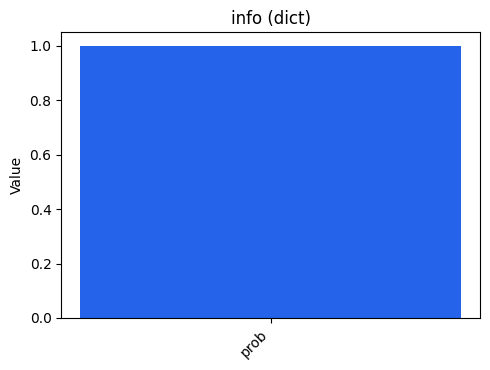

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Good RL work begins with problem formulation: choosing a useful state, a realistic action space, and a reward that matches the real goal.

**If students remember one idea:** Many RL failures come from poor problem definition, not from the algorithm itself.

**Quick check before moving on:**
- Can you redesign a bad reward so it better reflects the true objective?
- Can you explain why missing state information can make learning impossible?

**Bridge to the next step:** The mini-project lesson shows how these design choices appear in practical RL experiments.
